In [ ]:
import sys

sys.path.insert(1, '../ML_pipeline')
from data_preprocessing import HeartbeatDataProcessor

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE

In [2]:
folder_path='../data/PAMAP2_Dataset/Protocol/'
filtered_df_path='../ML_pipeline/'
processed_data = HeartbeatDataProcessor(folder_path,filtered_df_path)
processed_data.preprocess_subjects(range(101,109))

Selected DataFrame columns have 0.2913% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.019% NaNs!

successfully loaded subject 101
Selected DataFrame columns have 0.4147% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0327% NaNs!

successfully loaded subject 102
Selected DataFrame columns have 0.1624% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0117% NaNs!

successfully loaded subject 103
Selected DataFrame columns have 0.3568% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0095% NaNs!

successfully loaded subject 104
Selected DataFrame columns have 0.3409% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0268% NaNs!

successfully loaded subject 105
Selected DataFrame columns have 0.2521% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0349% NaNs!

successfully loaded subject 106
Selected DataFrame colu

In [3]:
slices = processed_data.subject_segment_dict[101]
for i in range(101,109):
    slices.extend(processed_data.subject_segment_dict[i])

feature_rows = []
labels = []
groups = []

for slice in slices:
    if slice.empty:
        continue

    # Column 1 is activity id in PAMAP2 raw files.
    # label = int(slice['activity_id'].mode().iloc[0])
    label = int(slice[1].mode().iloc[0])

    # Keep numeric sensor columns, excluding metadata/label columns.
    # drop_cols = ['timestamp', 'activity_id','heart_rate', 'hand_acc6_x','hand_acc6_y','hand_acc6_z','hand_orient_w', 'hand_orient_x', 'hand_orient_y', 'hand_orient_z',
    #              'chest_acc6_x', 'chest_acc6_y', 'chest_acc6_z',
    #              'chest_orient_x', 'chest_orient_y', 'chest_orient_z',
    #              'ankle_acc6_x', 'ankle_acc6_y', 'ankle_acc6_z',
    #              'ankle_orient_x', 'ankle_orient_y', 'ankle_orient_z',
    #              "subject_id", "interval_id"]
    drop_cols = [0, 1,2, 7,8,9,16,17,18,19,24,25,26,33,34,35,36,41,42,43,50,51,52,53, "subject_id", "interval_id"]
    sensor_df = slice.drop(columns=drop_cols, errors="ignore")
    sensor_df = sensor_df.select_dtypes(include=[np.number])

    if sensor_df.shape[1] == 0:
        continue

    row = {}
    for col in sensor_df.columns:
        values = sensor_df[col]
        row[f"c{col}_mean"] = values.mean()
        row[f"c{col}_std"] = values.std()
        row[f"c{col}_min"] = values.min()
        row[f"c{col}_max"] = values.max()

    feature_rows.append(row)
    labels.append(label)
    groups.append(int(slice["interval_id"].iloc[0]))


In [4]:
X = pd.DataFrame(feature_rows)
y = pd.Series(labels, name="activity_id")
groups = pd.Series(groups, name="interval_id")

X.to_csv('./X.csv')
y.to_csv('./y.csv')
groups.to_csv('./groups.csv')

In [5]:
# X = pd.read_csv('./X.csv')
# y = pd.read_csv('./y.csv')
# groups = pd.read_csv('./groups.csv')


print(f"X shape: {X.shape}")
print("Class counts:")
print(y.value_counts().sort_index())

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

def run_KNN(n_neighbors=5,weights='uniform'):

    rf_pipeline = Pipeline([
        (
            "KNN",
            KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights=weights,
                n_jobs=-1,
            ),
        ),
    ])

    rf_pipeline.fit(X_train, y_train)
    y_pred = rf_pipeline.predict(X_test)

    labels_sorted = np.sort(np.unique(np.concatenate([y_test.to_numpy(), y_pred])))
    cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=labels_sorted),
    index=[f"true_{lbl}" for lbl in labels_sorted],
    columns=[f"pred_{lbl}" for lbl in labels_sorted],
    )

    acc_score = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)

    return acc_score,report,cm


#loop through hyperparameters
k_vals = [5,10,20,30,50]
weight_vals = ['uniform','distance']

acc_dict = {}
report_dict = {}
cm_dict = {}

for weights in weight_vals:
    for k in k_vals:
        acc_score,report,cm = run_KNN(n_neighbors=k,weights=weights)

        label = weights + '-' + str(k)
        acc_dict[label] = acc_score
        report_dict[label] = report
        cm_dict[label] = cm

X shape: (20434, 120)
Class counts:
activity_id
1     2089
2     1980
3     2007
4     2507
5     1111
6     1786
7     1988
12    1114
13     968
16    1875
17    2514
24     495
Name: count, dtype: int64


In [6]:
print(acc_dict)

{'uniform-5': 0.7084208070912059, 'uniform-10': 0.6930254257056216, 'uniform-20': 0.6797294145089806, 'uniform-30': 0.6769302542570562, 'uniform-50': 0.66876603685561, 'distance-5': 0.7107534406344763, 'distance-10': 0.6983904828551435, 'distance-20': 0.6853277350128295, 'distance-30': 0.6832283648238862, 'distance-50': 0.6748308840681129}


In [53]:
ind = np.arange(0,len(X))
ind_pick = np.random.choice(ind,size=2000)

X_plot = X.iloc[ind_pick]
y_plot = y.iloc[ind_pick]

labels = y_plot.unique()
labels.sort()

tsne = TSNE(n_components=2, random_state=0)
X_2d = tsne.fit_transform(X_plot)

print(labels)


[ 1  2  3  4  5  6  7 12 13 16 17 24]


C:\Users\Charlie\AppData\Local\Temp\ipykernel_25928\1930949959.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_2d[y_plot == i, 0], X_2d[y_plot == i, 1], c=c, label=activity_map[label],s=5)


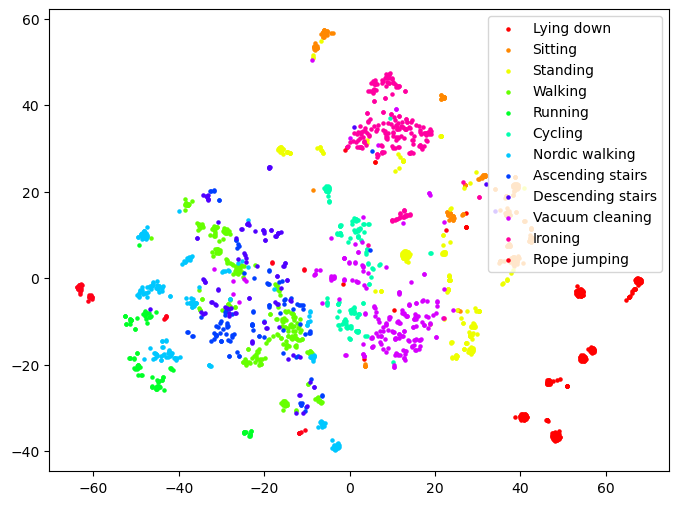

In [54]:
activity_map = {
    0: 'Transient/Break', 1: 'Lying down', 2: 'Sitting', 3: 'Standing', 
    4: 'Walking', 5: 'Running', 6: 'Cycling', 7: 'Nordic walking', 
    9: 'Watching TV', 10: 'Computer work', 11: 'Car driving', 
    12: 'Ascending stairs', 13: 'Descending stairs', 16: 'Vacuum cleaning', 
    17: 'Ironing', 18: 'Folding laundry', 19: 'House cleaning', 
    20: 'Playing soccer', 24: 'Rope jumping'
}

from matplotlib import pyplot as plt
plt.figure(figsize=(8, 6))

cmap = plt.get_cmap('hsv')
colors = cmap(np.arange(0,len(labels))/(len(labels)-1))
for i, c, label in zip(labels, colors, labels):
    plt.scatter(X_2d[y_plot == i, 0], X_2d[y_plot == i, 1], c=c, label=activity_map[label],s=5)
plt.legend()
plt.show()